<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Thin_Film_Adhesion_Predictions_for_Metals_on_Substrates.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

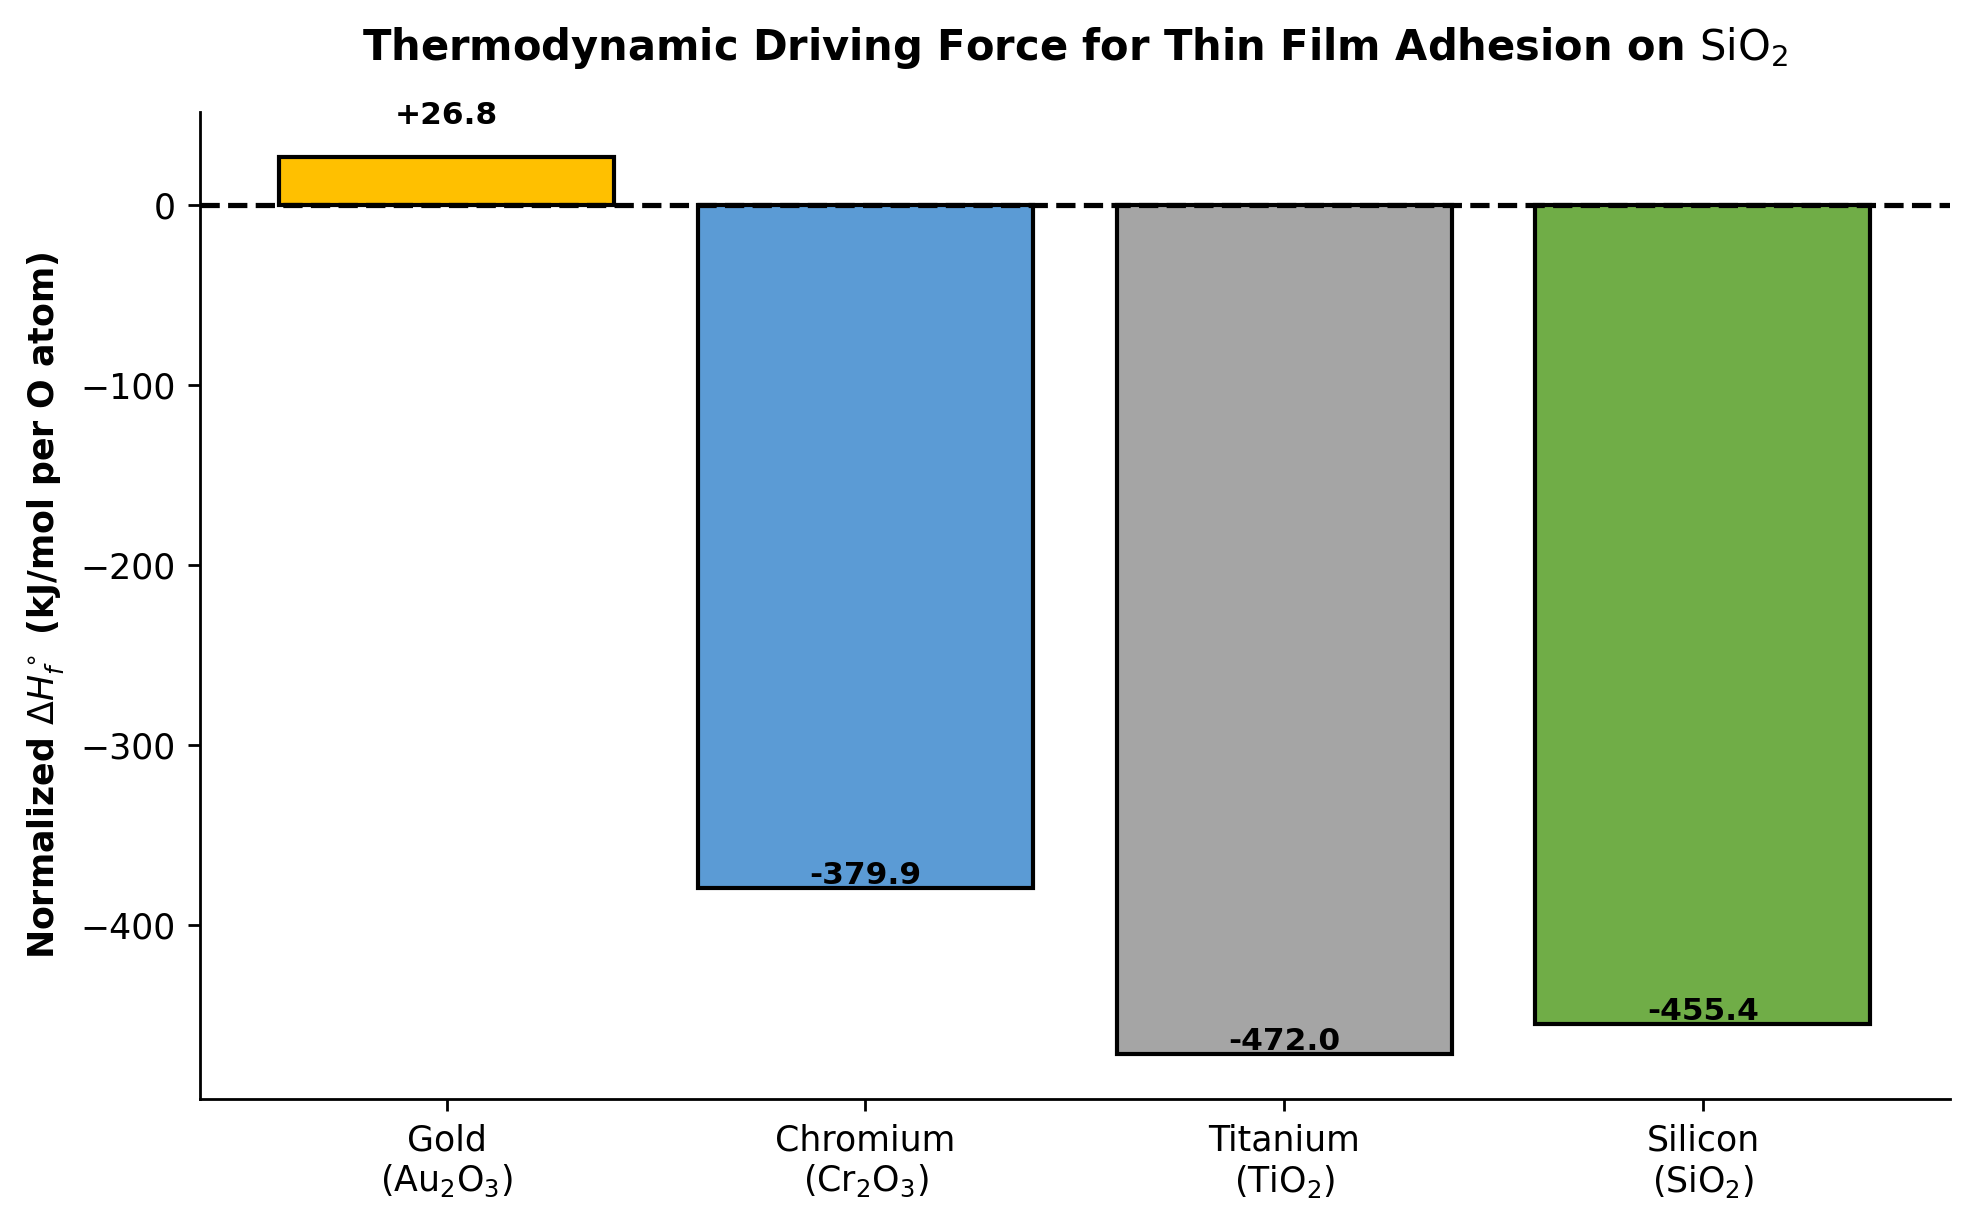

In [1]:
"""
Thermodynamic visualization of thin-film adhesion on oxide substrates.

This module plots the standard enthalpy of oxide formation (normalized per
mole of oxygen atoms) for gold, chromium, titanium, and silicon to
demonstrate the chemical driving forces governing thin-film adhesion.
"""

# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#5B9BD5', '#A5A5A5', '#70AD47']

# Thermodynamic and Material Parameters
OXYGEN_MOL_DIVISORS = [3.0, 3.0, 2.0, 2.0]
RAW_ENTHALPIES = [80.3, -1139.7, -944.0, -910.9]
LABELS = [
    'Gold\n($\\text{Au}_2\\text{O}_3$)',
    'Chromium\n($\\text{Cr}_2\\text{O}_3$)',
    'Titanium\n($\\text{TiO}_2$)',
    'Silicon\n($\\text{SiO}_2$)'
]

# Textual Plot Elements
PLOT_TITLE = 'Thermodynamic Driving Force for Thin Film Adhesion on $\\text{SiO}_2$'
Y_AXIS_LABEL = r'Normalized $\Delta H_f^\circ$ (kJ/mol per O atom)'

# ------------------------------

def plot_oxide_formation_enthalpies() -> None:
    """
    Generates and displays a bar chart comparing the normalized
    standard enthalpies of oxide formation for various metals.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data is
    normalized per mole of oxygen atoms to facilitate an equivalent
    thermodynamic comparison of interfacial oxygen affinity.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    raw_enthalpies_array = np.array(RAW_ENTHALPIES)
    divisors_array = np.array(OXYGEN_MOL_DIVISORS)
    normalized_enthalpies = raw_enthalpies_array / divisors_array

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        normalized_enthalpies,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2
    )

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    for bar, enthalpy in zip(bars, normalized_enthalpies):
        yval = bar.get_height()
        offset = 15 if yval > 0 else -25
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + np.sign(yval) * offset - (0 if yval > 0 else 10),
            f'{enthalpy:+.1f}',
            ha='center',
            va='bottom' if yval > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_oxide_formation_enthalpies()

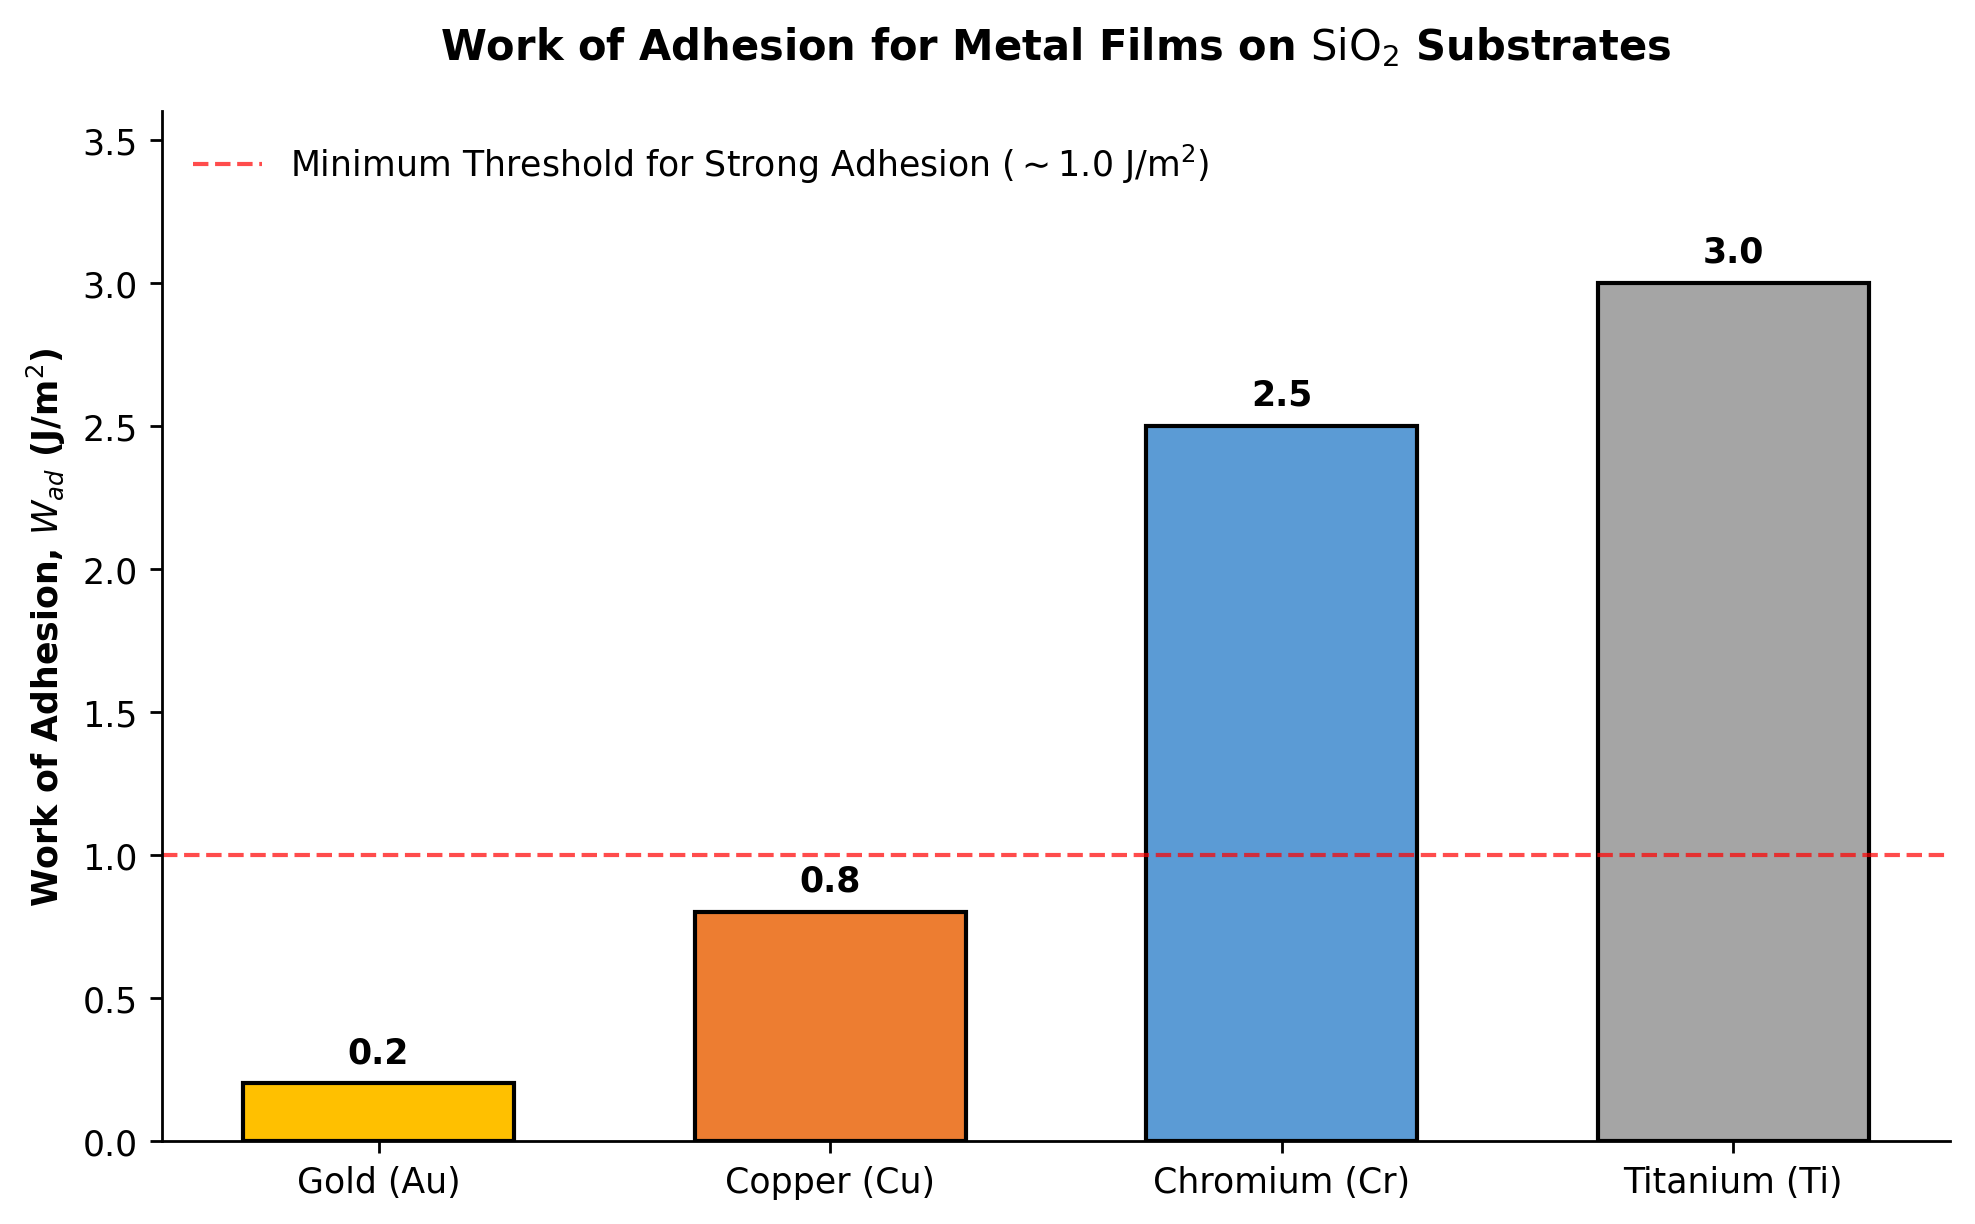

In [2]:
"""
Thermodynamic visualization of the Work of Adhesion for thin films.

This module plots the Work of Adhesion (W_ad) for various metals
on a silicon dioxide substrate to demonstrate the necessity of
reactive adhesion layers (like Ti or Cr) for noble metal deposition.
"""

import matplotlib.pyplot as plt
import numpy as np


def plot_work_of_adhesion() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a SiO2 substrate.

    The plot is optimized for inline Colab rendering at 250 DPI.
    Data represents typical empirical values (J/m^2) derived from
    sessile drop contact angle measurements and the Young-Dupré equation.
    """
# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv:
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#ED7D31', '#5B9BD5', '#A5A5A5']
THRESHOLD_COLOR = 'red'
BAR_WIDTH = 0.6

# Thermodynamic and Material Parameters
LABELS = [
    'Gold (Au)',
    'Copper (Cu)',
    'Chromium (Cr)',
    'Titanium (Ti)'
]
W_AD_VALUES = [0.2, 0.8, 2.5, 3.0]
ADHESION_THRESHOLD = 1.0

# Textual Plot Elements
PLOT_TITLE = 'Work of Adhesion for Metal Films on $\\text{SiO}_2$ Substrates'
Y_AXIS_LABEL = r'Work of Adhesion, $W_{ad}$ (J/m$^2$)'
THRESHOLD_LABEL = r'Minimum Threshold for Strong Adhesion ($\sim 1.0$ J/m$^2$)'

# ------------------------------

def plot_work_of_adhesion() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a silicon dioxide substrate.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data
    represents typical empirical values derived from sessile drop
    contact angle measurements and the fundamental Young-Dupré equation.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    w_ad_array = np.array(W_AD_VALUES)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        w_ad_array,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2,
        width=BAR_WIDTH
    )

    ax.axhline(
        ADHESION_THRESHOLD,
        color=THRESHOLD_COLOR,
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=THRESHOLD_LABEL
    )

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    ax.set_ylim(0, np.max(w_ad_array) * 1.2)

    for bar, w_ad in zip(bars, w_ad_array):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{w_ad:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_work_of_adhesion()

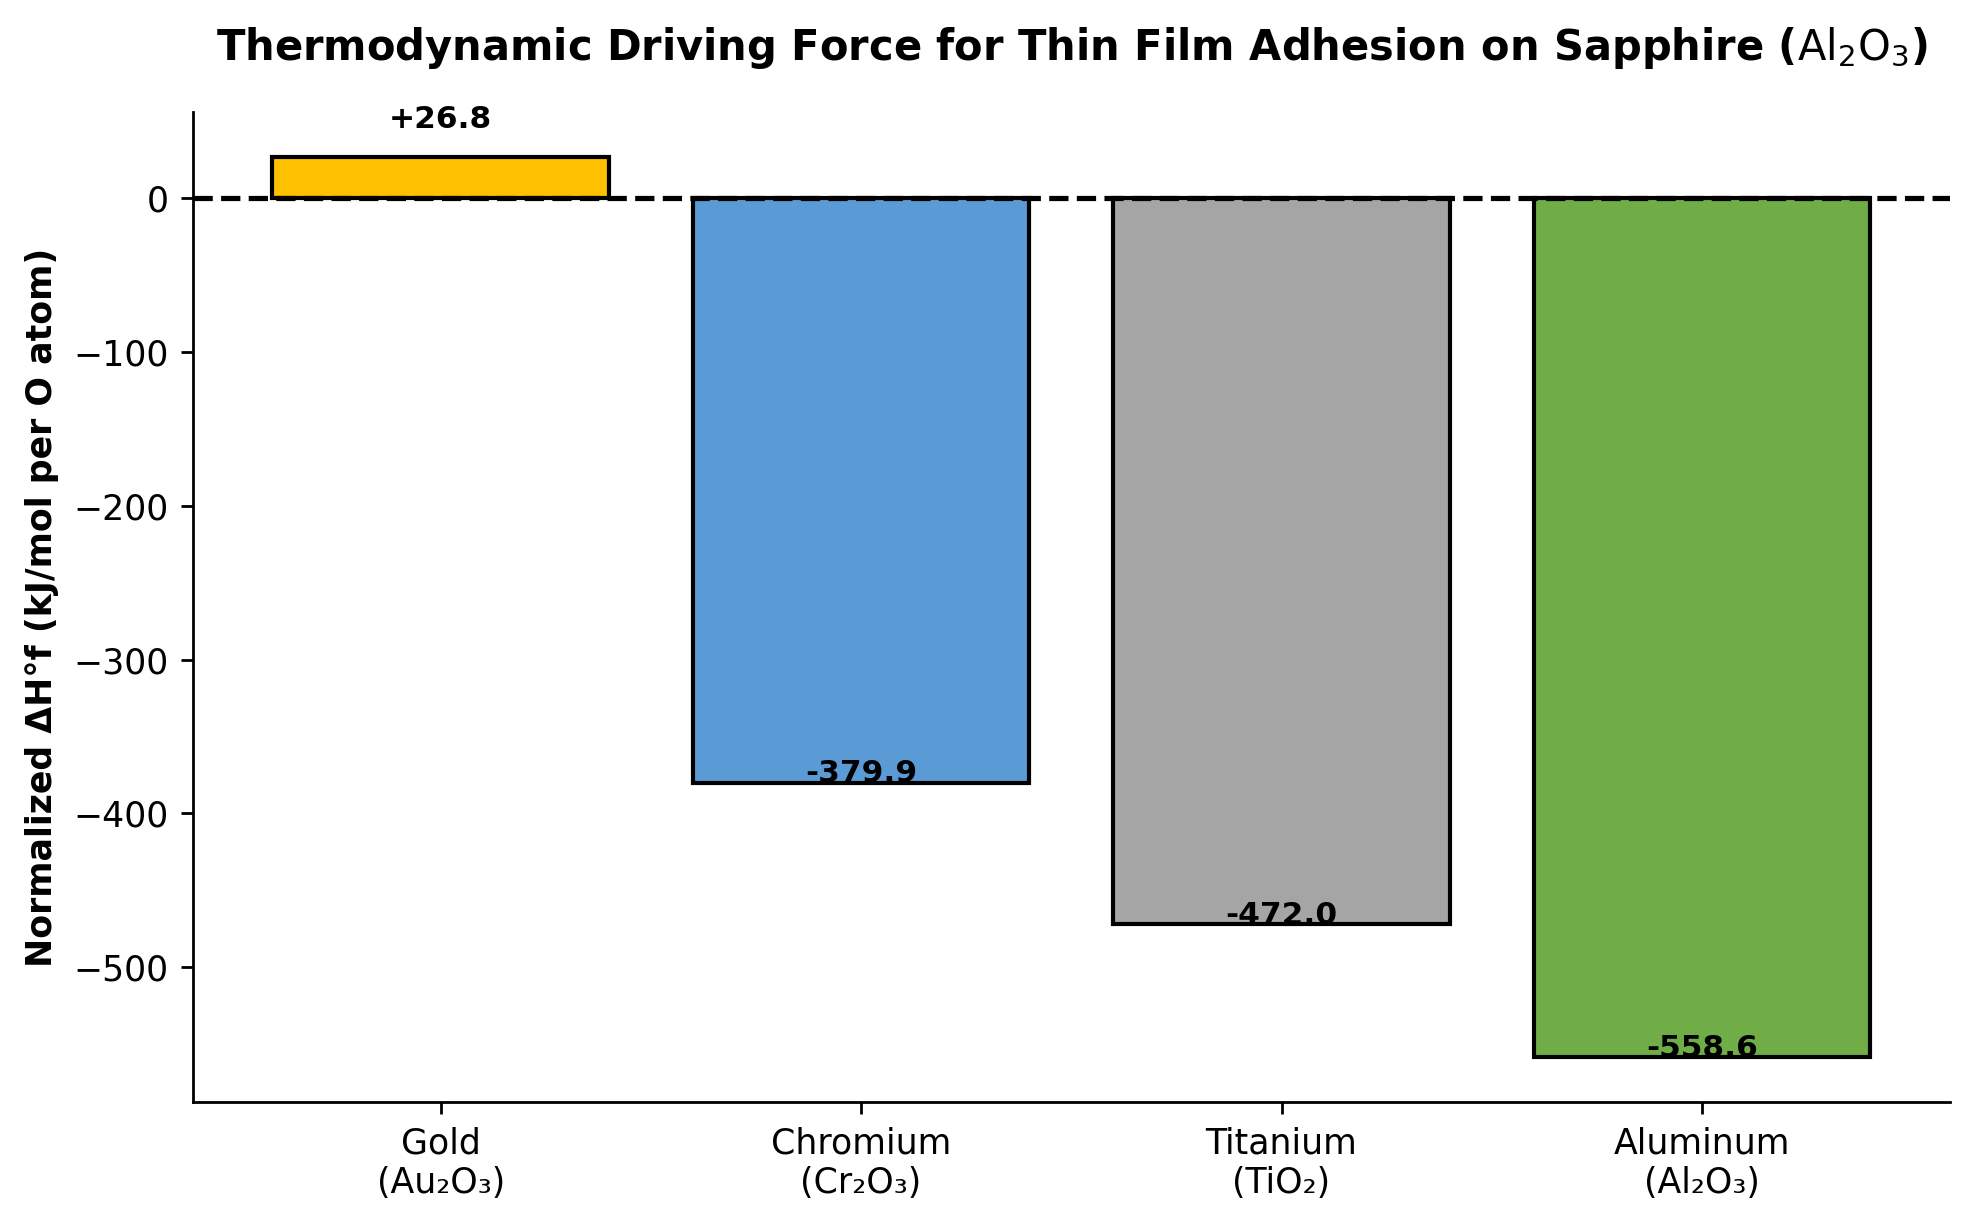

In [6]:
"""
Thermodynamic visualization of thin-film adhesion on sapphire substrates.

This module plots the standard enthalpy of oxide formation (normalized per
mole of oxygen atoms) for gold, chromium, titanium, and aluminum. The
visualization elucidates the chemical driving forces governing metallic
thin-film adhesion on a highly stable aluminum oxide substrate.
"""

# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---
# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#5B9BD5', '#A5A5A5', '#70AD47']

# Thermodynamic and Material Parameters
OXYGEN_MOL_DIVISORS = [3.0, 3.0, 2.0, 3.0]
RAW_ENTHALPIES = [80.3, -1139.7, -944.0, -1675.7]
LABELS = [
    'Gold\n(Au₂O₃)',
    'Chromium\n(Cr₂O₃)',
    'Titanium\n(TiO₂)',
    'Aluminum\n(Al₂O₃)'
]

# Textual Plot Elements
PLOT_TITLE = 'Thermodynamic Driving Force for Thin Film Adhesion on Sapphire ($\\text{Al}_2\\text{O}_3$)'
Y_AXIS_LABEL = 'Normalized ΔH°f (kJ/mol per O atom)'

# ------------------------------

def plot_oxide_formation_enthalpies() -> None:
    """
    Generates and displays a bar chart comparing the normalized
    standard enthalpies of oxide formation for various metals.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data is
    normalized per mole of oxygen atoms to facilitate an equivalent
    thermodynamic comparison of interfacial oxygen affinity.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    raw_enthalpies_array = np.array(RAW_ENTHALPIES)
    divisors_array = np.array(OXYGEN_MOL_DIVISORS)
    normalized_enthalpies = raw_enthalpies_array / divisors_array

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        normalized_enthalpies,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2
    )

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    for bar, enthalpy in zip(bars, normalized_enthalpies):
        yval = bar.get_height()
        offset = 15 if yval > 0 else -25
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + np.sign(yval) * offset - (0 if yval > 0 else 10),
            f'{enthalpy:+.1f}',
            ha='center',
            va='bottom' if yval > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_oxide_formation_enthalpies()

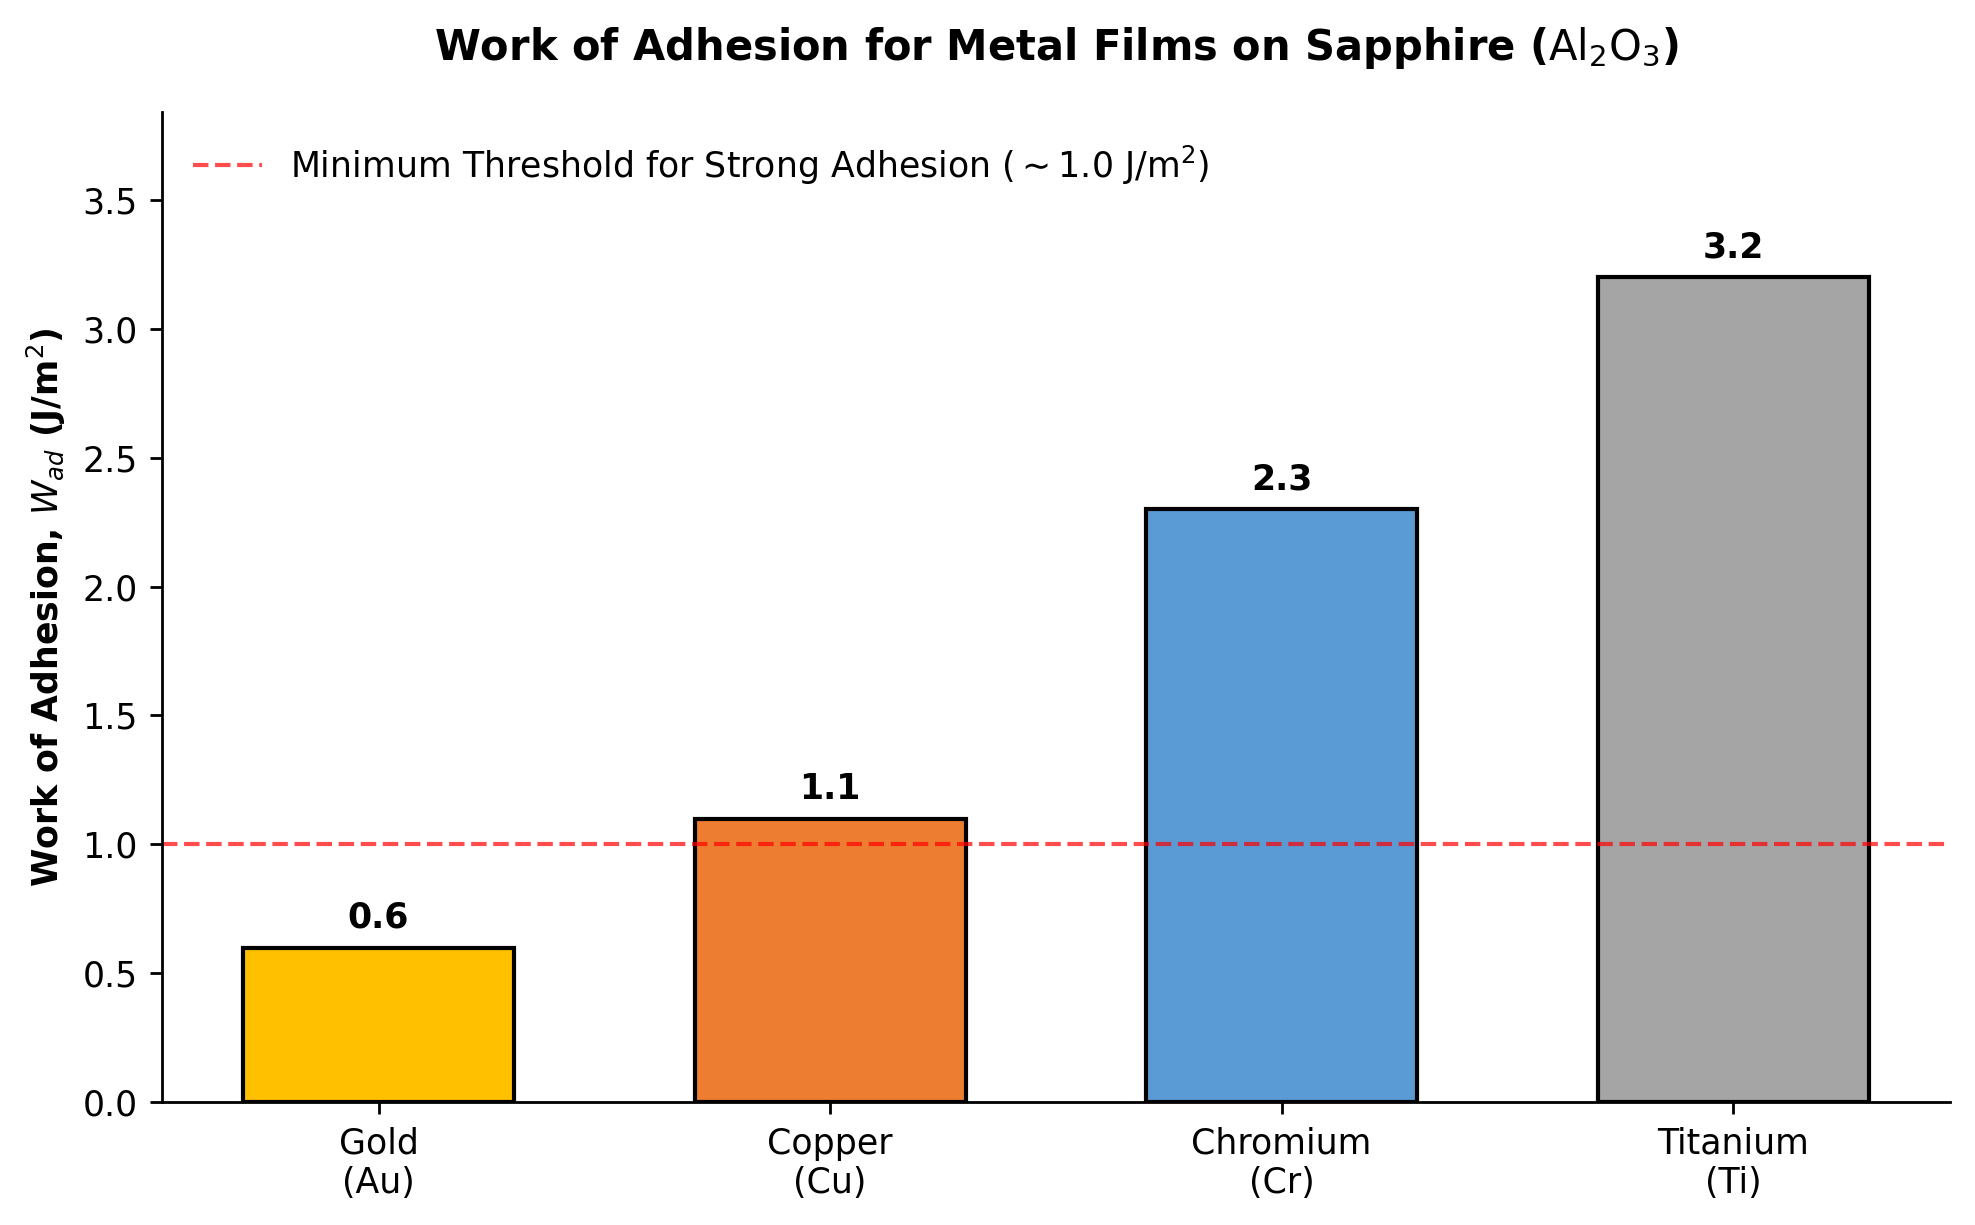

In [5]:
"""
Thermodynamic visualization of the Work of Adhesion for thin films on sapphire.

This module plots the Work of Adhesion (W_ad) for various transition and noble
metals on an aluminum oxide (sapphire) substrate to demonstrate the necessity
of reactive adhesion layers for stable thin-film deposition.
"""
# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#ED7D31', '#5B9BD5', '#A5A5A5']
THRESHOLD_COLOR = 'red'
BAR_WIDTH = 0.6

# Thermodynamic and Material Parameters
LABELS = [
    'Gold\n(Au)',
    'Copper\n(Cu)',
    'Chromium\n(Cr)',
    'Titanium\n(Ti)'
]
# Empirical Work of Adhesion values (J/m^2) for metals on Sapphire (Al2O3)
W_AD_VALUES = [0.6, 1.1, 2.3, 3.2]
ADHESION_THRESHOLD = 1.0

# Textual Plot Elements
PLOT_TITLE = 'Work of Adhesion for Metal Films on Sapphire ($\\text{Al}_2\\text{O}_3$)'
Y_AXIS_LABEL = 'Work of Adhesion, $W_{ad}$ (J/m$^2$)'
THRESHOLD_LABEL = 'Minimum Threshold for Strong Adhesion ($\\sim 1.0$ J/m$^2$)'

# ------------------------------

def plot_work_of_adhesion_sapphire() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a sapphire substrate.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data
    represents typical empirical values derived from sessile drop
    contact angle measurements and the fundamental Young-Dupré equation.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    w_ad_array = np.array(W_AD_VALUES)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        w_ad_array,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2,
        width=BAR_WIDTH
    )

    ax.axhline(
        ADHESION_THRESHOLD,
        color=THRESHOLD_COLOR,
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=THRESHOLD_LABEL
    )

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    ax.set_ylim(0, np.max(w_ad_array) * 1.2)

    for bar, w_ad in zip(bars, w_ad_array):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{w_ad:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_work_of_adhesion_sapphire()

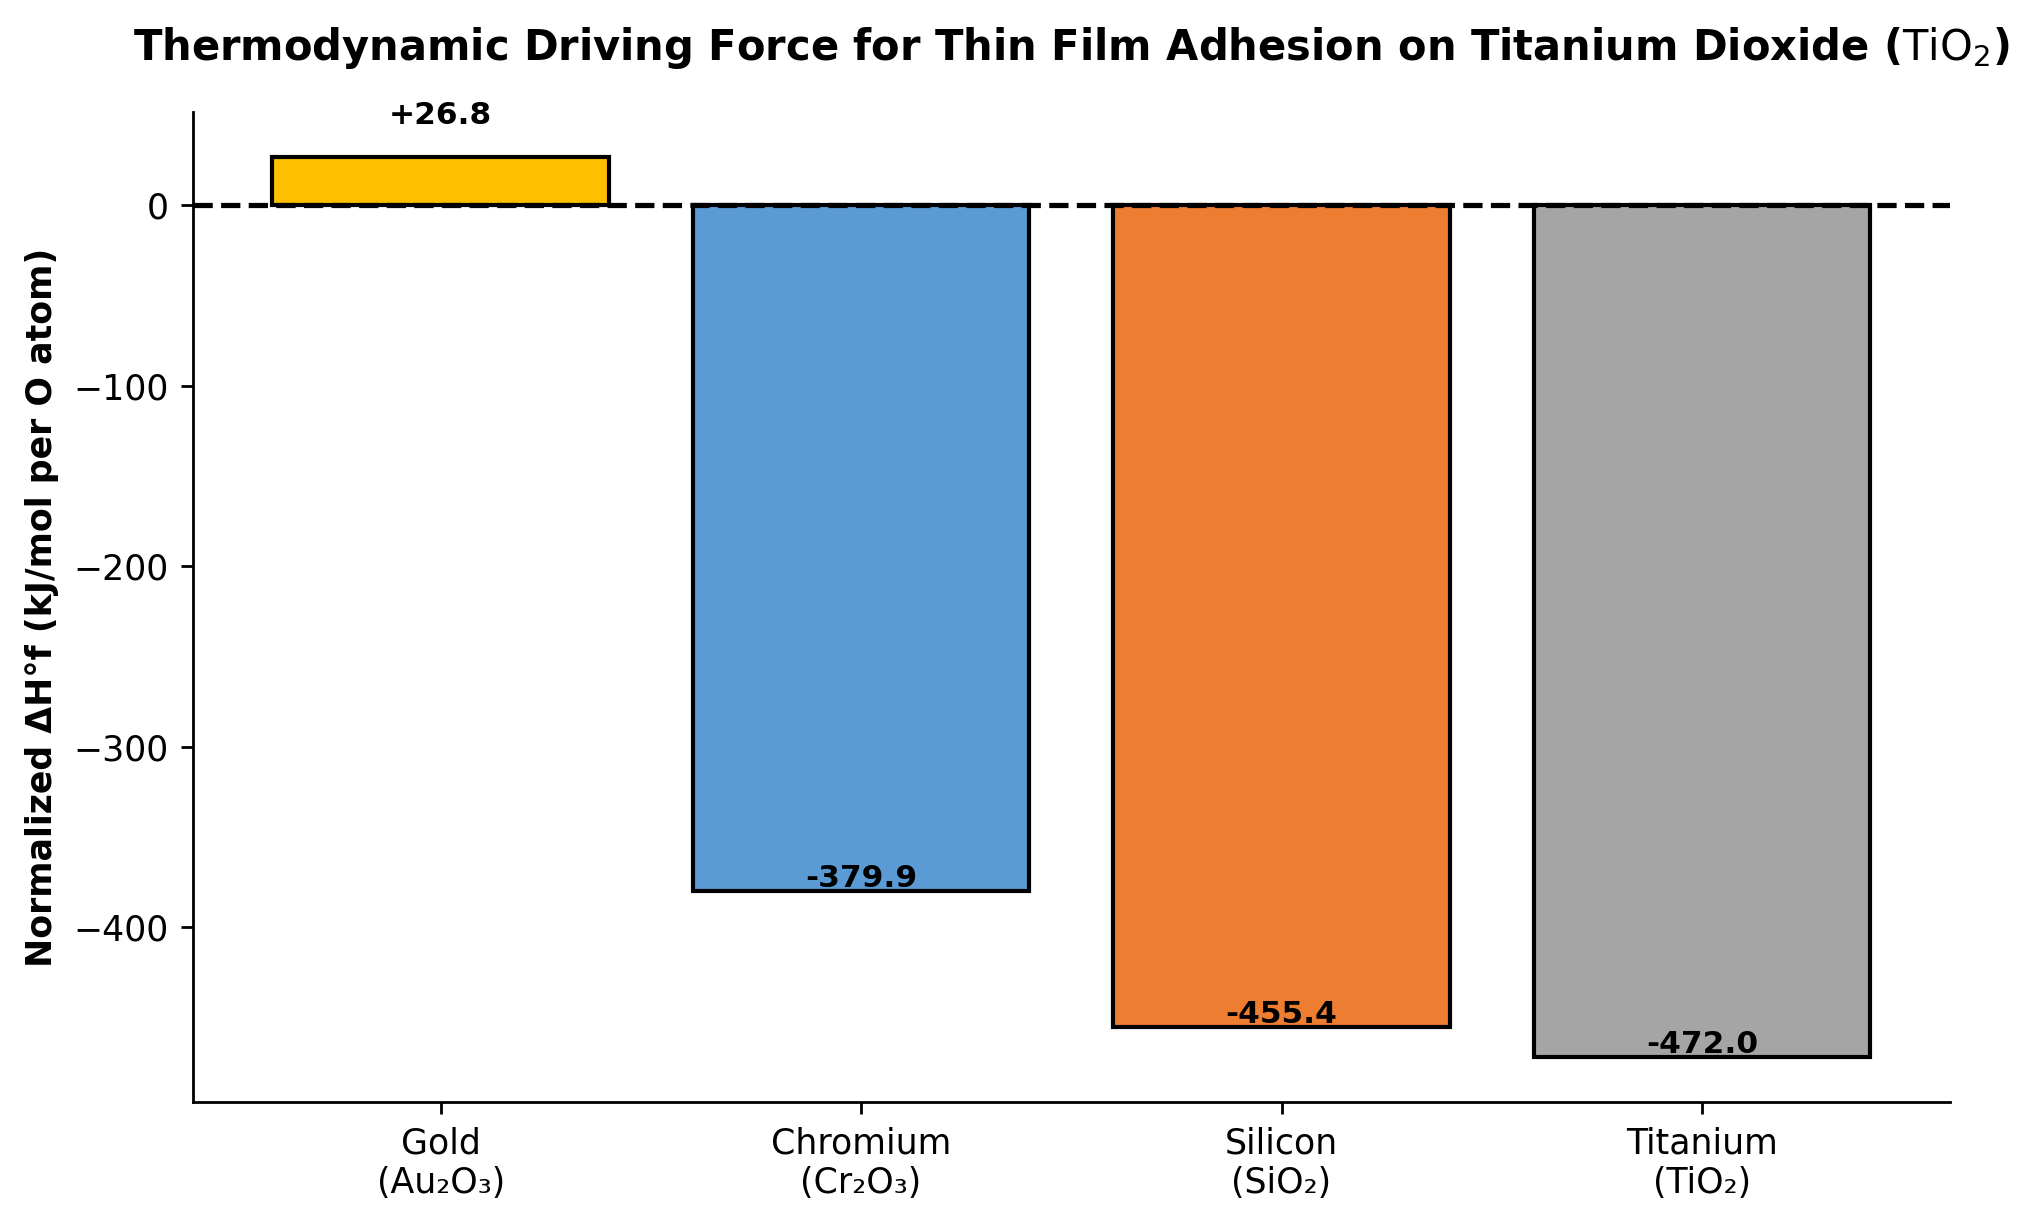

In [7]:
"""
Thermodynamic visualization of thin-film adhesion on titanium dioxide substrates.

This module plots the standard enthalpy of oxide formation (normalized per
mole of oxygen atoms) for gold, chromium, silicon, and titanium. The
visualization elucidates the chemical driving forces governing metallic
thin-film adhesion on a titanium dioxide substrate.
"""

# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---
# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#5B9BD5', '#ED7D31', '#A5A5A5']

# Thermodynamic and Material Parameters
OXYGEN_MOL_DIVISORS = [3.0, 3.0, 2.0, 2.0]
RAW_ENTHALPIES = [80.3, -1139.7, -910.9, -944.0]
LABELS = [
    'Gold\n(Au₂O₃)',
    'Chromium\n(Cr₂O₃)',
    'Silicon\n(SiO₂)',
    'Titanium\n(TiO₂)'
]

# Textual Plot Elements
PLOT_TITLE = 'Thermodynamic Driving Force for Thin Film Adhesion on Titanium Dioxide ($\\text{TiO}_2$)'
Y_AXIS_LABEL = 'Normalized ΔH°f (kJ/mol per O atom)'

# ------------------------------

def plot_oxide_formation_enthalpies() -> None:
    """
    Generates and displays a bar chart comparing the normalized
    standard enthalpies of oxide formation for various metals.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. Data is
    normalized per mole of oxygen atoms to facilitate an equivalent
    thermodynamic comparison of interfacial oxygen affinity.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    raw_enthalpies_array = np.array(RAW_ENTHALPIES)
    divisors_array = np.array(OXYGEN_MOL_DIVISORS)
    normalized_enthalpies = raw_enthalpies_array / divisors_array

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        normalized_enthalpies,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2
    )

    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    for bar, enthalpy in zip(bars, normalized_enthalpies):
        yval = bar.get_height()
        offset = 15 if yval > 0 else -25
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + np.sign(yval) * offset - (0 if yval > 0 else 10),
            f'{enthalpy:+.1f}',
            ha='center',
            va='bottom' if yval > 0 else 'top',
            fontsize=9,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_oxide_formation_enthalpies()

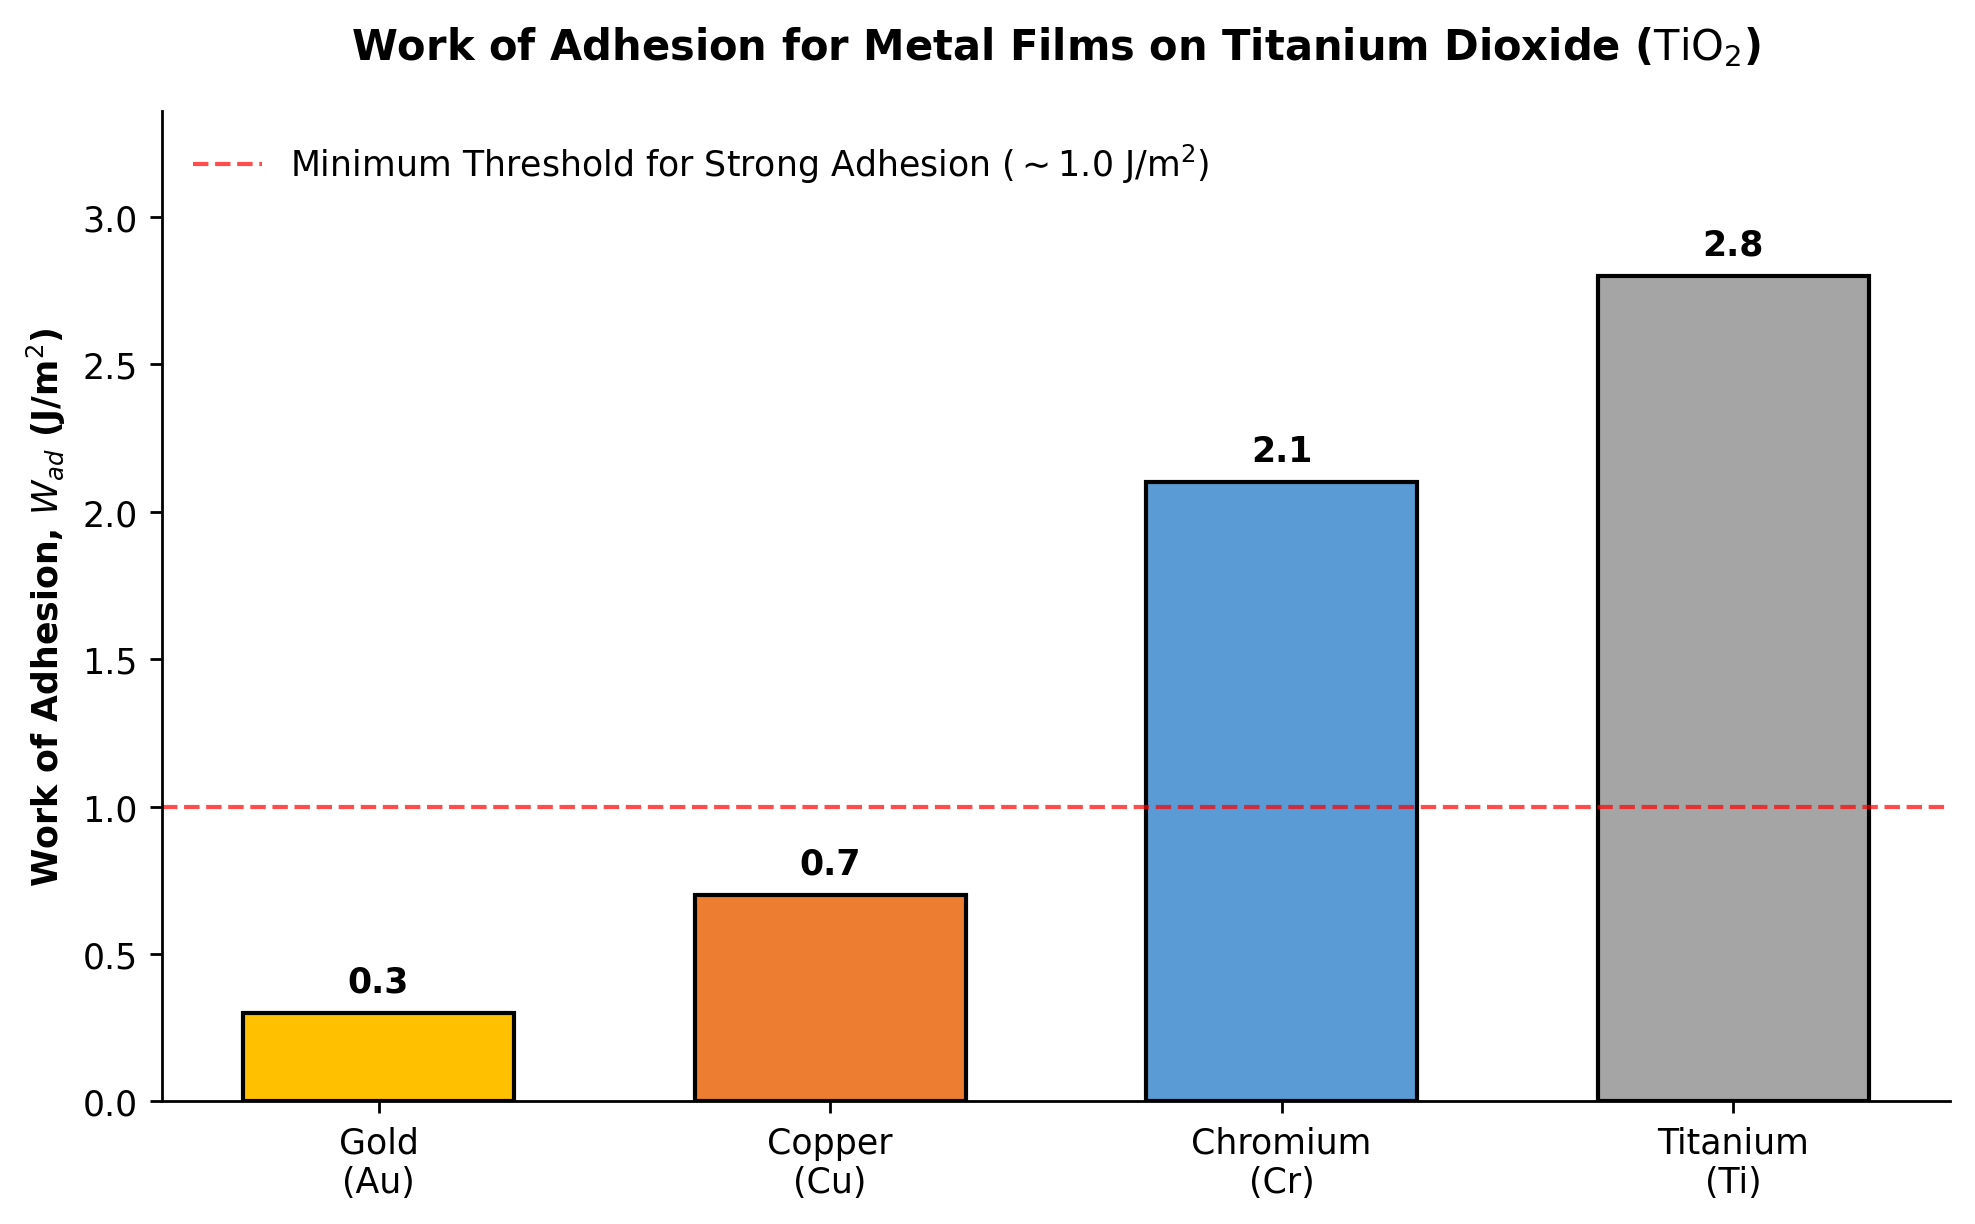

In [8]:
"""
Thermodynamic visualization of the Work of Adhesion for thin films on titanium dioxide.

This module plots the Work of Adhesion (W_ad) for various transition and noble
metals on a titanium dioxide (TiO2) substrate. The analytical framework
demonstrates the necessity of reactive adhesion layers to achieve stable
thin-film deposition by exceeding the minimum empirical adhesion threshold.
"""

# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (8, 5)
COLORS = ['#FFC000', '#ED7D31', '#5B9BD5', '#A5A5A5']
THRESHOLD_COLOR = 'red'
BAR_WIDTH = 0.6

# Thermodynamic and Material Parameters
LABELS = [
    'Gold\n(Au)',
    'Copper\n(Cu)',
    'Chromium\n(Cr)',
    'Titanium\n(Ti)'
]
# Empirical Work of Adhesion values (J/m^2) for metals on Titanium Dioxide (TiO2)
W_AD_VALUES = [0.3, 0.7, 2.1, 2.8]
ADHESION_THRESHOLD = 1.0

# Textual Plot Elements
PLOT_TITLE = 'Work of Adhesion for Metal Films on Titanium Dioxide ($\\text{TiO}_2$)'
Y_AXIS_LABEL = 'Work of Adhesion, $W_{ad}$ (J/m$^2$)'
THRESHOLD_LABEL = 'Minimum Threshold for Strong Adhesion ($\\sim 1.0$ J/m$^2$)'

# ------------------------------

def plot_work_of_adhesion_titania() -> None:
    """
    Generates and displays a bar chart comparing the Work of Adhesion
    for different metals on a titanium dioxide substrate.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within computational notebook environments. Data
    represents typical empirical values derived from sessile drop
    contact angle measurements and the fundamental Young-Dupré equation.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    w_ad_array = np.array(W_AD_VALUES)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars = ax.bar(
        LABELS,
        w_ad_array,
        color=COLORS,
        edgecolor='black',
        linewidth=1.2,
        width=BAR_WIDTH
    )

    ax.axhline(
        ADHESION_THRESHOLD,
        color=THRESHOLD_COLOR,
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=THRESHOLD_LABEL
    )

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)

    ax.set_ylim(0, np.max(w_ad_array) * 1.2)

    for bar, w_ad in zip(bars, w_ad_array):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.05,
            f'{w_ad:.1f}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()

    plt.show()

if __name__ == '__main__':
    plot_work_of_adhesion_titania()

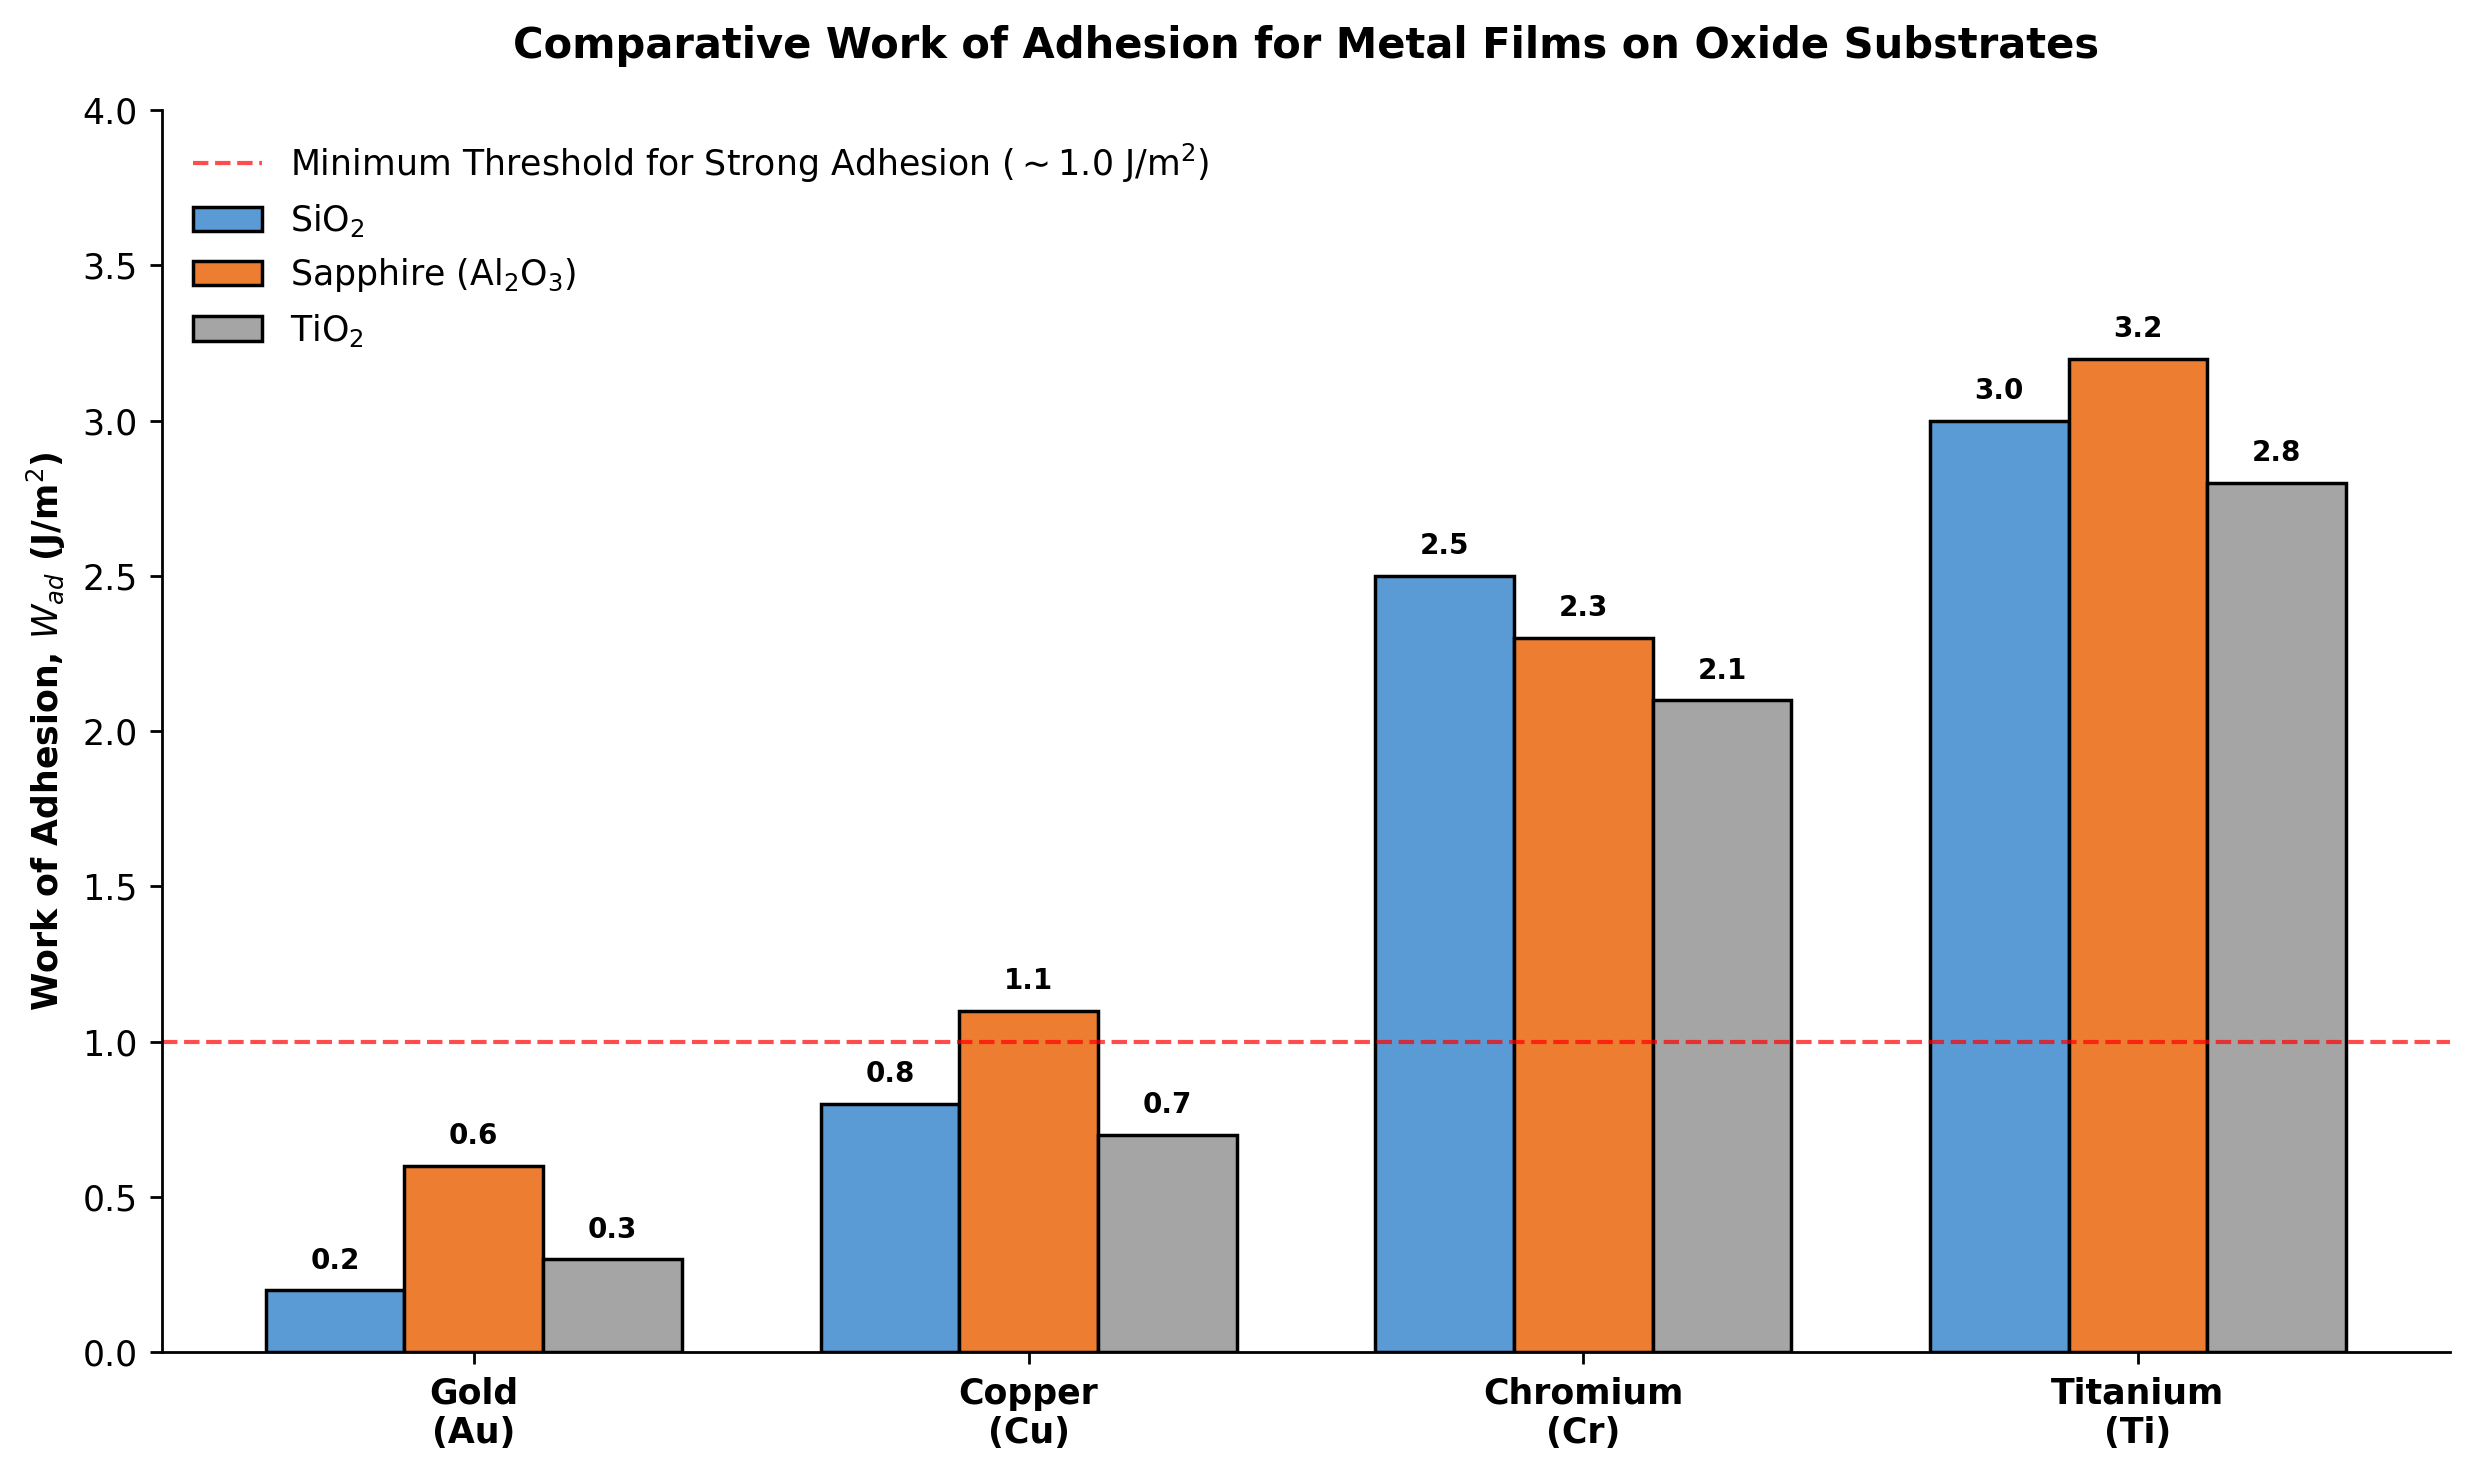

In [9]:
"""
Thermodynamic comparison of the Work of Adhesion across multiple oxide substrates.

This module plots the Work of Adhesion (W_ad) for gold, copper, chromium,
and titanium simultaneously across silicon dioxide, sapphire, and titanium
dioxide substrates. The comparative visualization elucidates the universal
necessity of reactive transition metals for establishing stable thin-film
interfaces across diverse structural ceramics.
"""

# Installation directive for the required scientific and visualization libraries.
# Execute the following command in your terminal or Colab environment using pip or uv
# pip install numpy matplotlib
# uv pip install numpy matplotlib

import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rcParams

# --- CONFIGURATION CONTROLS ---

# Aesthetic and Environmental Parameters
PLOT_DPI = 250
FONT_SANS_SERIF = ['Tahoma', 'DejaVu Sans']
FONT_WEIGHT = 'normal'
FIGURE_SIZE = (10, 6)
COLOR_SIO2 = '#5B9BD5'     # Blue
COLOR_AL2O3 = '#ED7D31'    # Orange
COLOR_TIO2 = '#A5A5A5'     # Gray
THRESHOLD_COLOR = 'red'
BAR_WIDTH = 0.25

# Thermodynamic and Material Parameters
LABELS = [
    'Gold\n(Au)',
    'Copper\n(Cu)',
    'Chromium\n(Cr)',
    'Titanium\n(Ti)'
]

# Empirical Work of Adhesion values (J/m^2) for each substrate
W_AD_SIO2 = [0.2, 0.8, 2.5, 3.0]
W_AD_AL2O3 = [0.6, 1.1, 2.3, 3.2]
W_AD_TIO2 = [0.3, 0.7, 2.1, 2.8]

ADHESION_THRESHOLD = 1.0

# Textual Plot Elements
PLOT_TITLE = 'Comparative Work of Adhesion for Metal Films on Oxide Substrates'
Y_AXIS_LABEL = 'Work of Adhesion, $W_{ad}$ (J/m$^2$)'
THRESHOLD_LABEL = 'Minimum Threshold for Strong Adhesion ($\\sim 1.0$ J/m$^2$)'

# ------------------------------

def plot_comparative_work_of_adhesion() -> None:
    """
    Generates and displays a grouped bar chart comparing the Work of Adhesion
    for different metals across three distinct oxide substrates.

    The plot incorporates specific font architectures and is optimized
    for inline rendering within Jupyter or Colab environments. The grouping
    logic aligns related thermodynamic values to facilitate direct visual
    comparisons of substrate-dependent chemical affinities.
    """
    rcParams['figure.dpi'] = PLOT_DPI
    rcParams['font.sans-serif'] = FONT_SANS_SERIF
    rcParams['font.weight'] = FONT_WEIGHT
    rcParams['font.size'] = 10

    x_indices = np.arange(len(LABELS))

    sio2_array = np.array(W_AD_SIO2)
    al2o3_array = np.array(W_AD_AL2O3)
    tio2_array = np.array(W_AD_TIO2)

    fig, ax = plt.subplots(figsize=FIGURE_SIZE)

    bars_sio2 = ax.bar(
        x_indices - BAR_WIDTH,
        sio2_array,
        color=COLOR_SIO2,
        edgecolor='black',
        linewidth=1.0,
        width=BAR_WIDTH,
        label='$\\text{SiO}_2$'
    )

    bars_al2o3 = ax.bar(
        x_indices,
        al2o3_array,
        color=COLOR_AL2O3,
        edgecolor='black',
        linewidth=1.0,
        width=BAR_WIDTH,
        label='Sapphire ($\\text{Al}_2\\text{O}_3$)'
    )

    bars_tio2 = ax.bar(
        x_indices + BAR_WIDTH,
        tio2_array,
        color=COLOR_TIO2,
        edgecolor='black',
        linewidth=1.0,
        width=BAR_WIDTH,
        label='$\\text{TiO}_2$'
    )

    ax.axhline(
        ADHESION_THRESHOLD,
        color=THRESHOLD_COLOR,
        linewidth=1.2,
        linestyle='--',
        alpha=0.7,
        label=THRESHOLD_LABEL
    )

    ax.set_ylabel(Y_AXIS_LABEL, fontweight='bold')
    ax.set_title(PLOT_TITLE, fontweight='bold', pad=15)
    ax.set_xticks(x_indices)
    ax.set_xticklabels(LABELS, fontweight='bold')

    max_val = max(np.max(sio2_array), np.max(al2o3_array), np.max(tio2_array))
    ax.set_ylim(0, max_val * 1.25)

    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.05,
                f'{height:.1f}',
                ha='center',
                va='bottom',
                fontsize=8,
                fontweight='bold',
                rotation=0
            )

    add_value_labels(bars_sio2)
    add_value_labels(bars_al2o3)
    add_value_labels(bars_tio2)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(frameon=False, loc='upper left')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    plot_comparative_work_of_adhesion()